In [2]:
# Deep Learning + Medics + Audio Data
# LSTM lifecycle + Cardiac working and heart sounds + Spectrum and MFCC

In [3]:
import tensorflow as tf

# Deep Learning things
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import concatenate

from tensorflow.keras.models import Sequential, Model, load_model

from tensorflow.keras.layers import Conv1D, Conv2D, SeparableConv1D, MaxPooling1D, MaxPooling2D
from tensorflow.keras.layers import Input, add, Flatten, Dense, BatchNormalization, Dropout, LSTM, GRU
from tensorflow.keras.layers import GlobalMaxPooling1D, GlobalMaxPooling2D, Activation, LeakyReLU, ReLU

from tensorflow.keras import regularizers
from tensorflow.keras import backend as k
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.metrics import cohen_kappa_score, roc_auc_score, confusion_matrix, classification_report

In [4]:
import kagglehub
import os # Fetch data
import glob
import pandas as pd # Loading data
import numpy as np # Processing
import librosa # For audio files
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt
import IPython.display as ipd
import fnmatch
import math

c:\Users\Sandeep\anaconda3\envs\new_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Load data from kaggle
path = kagglehub.dataset_download("abdallahaboelkhair/heartbeat-sound")
print("Path to dataset:", path)

Path to dataset: C:\Users\Sandeep\.cache\kagglehub\datasets\abdallahaboelkhair\heartbeat-sound\versions\1


In [6]:
base_path = r"C:\Users\Sandeep\.cache\kagglehub\datasets\abdallahaboelkhair\heartbeat-sound\versions\1\Heartbeat_Sound"

In [7]:
print(os.listdir(base_path))

['artifact', 'extrahls', 'extrastole', 'murmur', 'normal', 'unlabel']


In [8]:
unlable_data = base_path + "/unlabel/" 

normal_data = base_path + "/normal/"
murmur_data = base_path + "/murmur/"
extrastole_data = base_path + "/extrastole/"
artifact_data = base_path + "/artifact/"
extrahls_data = base_path + "/extrahls/"

In [9]:
# All Training data
print("noraml files", len(os.listdir(normal_data)))
print("murmur files", len(os.listdir(murmur_data)))
print("extrastole files", len(os.listdir(extrastole_data)))
print("artifact files", len(os.listdir(artifact_data)))
print("extrahls files", len(os.listdir(extrahls_data)))

noraml files 351
murmur files 129
extrastole files 46
artifact files 40
extrahls files 19


In [10]:
# Test Data
print("test files", len(os.listdir(unlable_data)))

test files 247


# EDA

([<matplotlib.patches.Wedge at 0x198d607d060>,
 [Text(-0.5098783100995935, 1.569243164359808, 'normal'),
  Text(-0.40776215320264214, -1.5988214491979853, 'murmur'),
  Text(1.050383523907315, -1.272475717923156, 'extrastole'),
  Text(1.5073501146290595, -0.671115215091836, 'artifact'),
  Text(1.641418359701695, -0.16806477451922466, 'extrahls')],
 [Text(-0.27811544187250553, 0.8559508169235315, '60%'),
  Text(-0.22241571992871384, -0.8720844268352645, '22%'),
  Text(0.5729364675858081, -0.6940776643217214, '8%'),
  Text(0.8221909716158505, -0.3660628445955469, '7%'),
  Text(0.8953191052918333, -0.09167169519230435, '3%')])

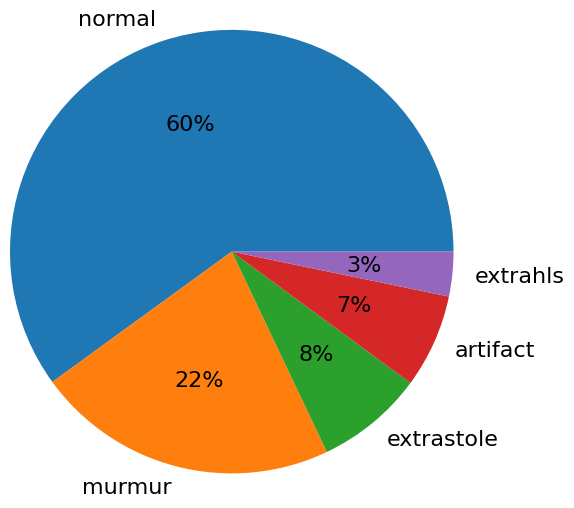

In [11]:
# Pie chart visualization
X = np.array([len(os.listdir(normal_data)), len(os.listdir(murmur_data)), len(os.listdir(extrastole_data)), len(os.listdir(artifact_data)), len(os.listdir(extrahls_data))])

labels = ["normal", "murmur", "extrastole", "artifact", "extrahls"]

plt.pie(X, labels = labels, radius = 1.5, textprops = {"fontsize": 16}, autopct = "%.0f%%")

In [12]:
# Listen to a random sound from given data
def rand_snd(audio_class):
    random_sound = np.random.randint(0, len((os.listdir(audio_class))))
    sound = os.listdir(audio_class)[random_sound]
    sound = audio_class + sound
    sound, sample_rate = librosa.load(sound)
    return ipd.Audio(sound, rate = sample_rate), sound


In [13]:
# Show waveform of the audio
# Study amplitude
def waveform(audio_sample):
    plt.figure(figsize = (20, 5))
    librosa.display.waveshow(audio_sample, sr = 22050)
    plt.title("Sound")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()

In [14]:
# Show Specturm of the audio
def spectrum(audio_sample):
    sample_rate = 22050
    fft_normal = np.fft.fft(audio_sample)   # Fourier version
    magnitude_normal = np.abs(fft_normal)   # Converts -ve into +ve
    freq_noraml = np.linspace(0, sample_rate, len(magnitude_normal))
    half_freq = freq_noraml[:int(len(freq_noraml)/2)]
    half_magnitude = magnitude_normal[:int(len(freq_noraml)/2)]

    plt.figure(figsize = (12, 8))
    plt.plot(half_freq, half_magnitude)
    plt.title("Spectrrurm")
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")
    plt.show()

In [15]:
# Spectogram
def spectrogram(audio_sample):
    sample_rate = 22050
    hop_length = 512
    n_fft = 2048

    hop_duration = float(hop_length) / sample_rate
    n_fft_duration = float(n_fft) / sample_rate

    print("Hop Length Duration (sec):", hop_duration)
    print("FFT Window Duration (sec):", n_fft_duration)

    stft_noraml = librosa.stft(audio_sample, n_fft=n_fft, hop_length=hop_length)
    
    spectrogram = np.abs(stft_noraml)
    log_stectogram = librosa.amplitude_to_db(spectrogram)

    plt.figure(figsize=(15,10))
    librosa.display.specshow(log_stectogram, sr = sample_rate, hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("Frrequency")
    plt.colorbar()
    plt.title("Spectrogram")
    

In [16]:
# Mel-frrequency (Converts audio into numbers)
def MFCC(audio_sample):
    sample_rate = 22050
    hop_length = 512
    n_fft = 2048

    MFCC = librosa.feature.mfcc(y = audio_sample, sr = sample_rate, n_fft = n_fft, hop_length = hop_length, n_mfcc = 52) # Extracting 52 features from audio

    plt.figure(figsize=(15,10))
    librosa.display.specshow(MFCC, sr = sample_rate, hop_length=hop_length)
    plt.title("MFCC")
    plt.xlabel("Time")
    plt.ylabel("MFCC_coefficience")
    plt.colorbar()
    plt.show()

### Visualize all the given sounds

In [17]:
normal_audio, normal_sample = rand_snd(normal_data)
normal_audio

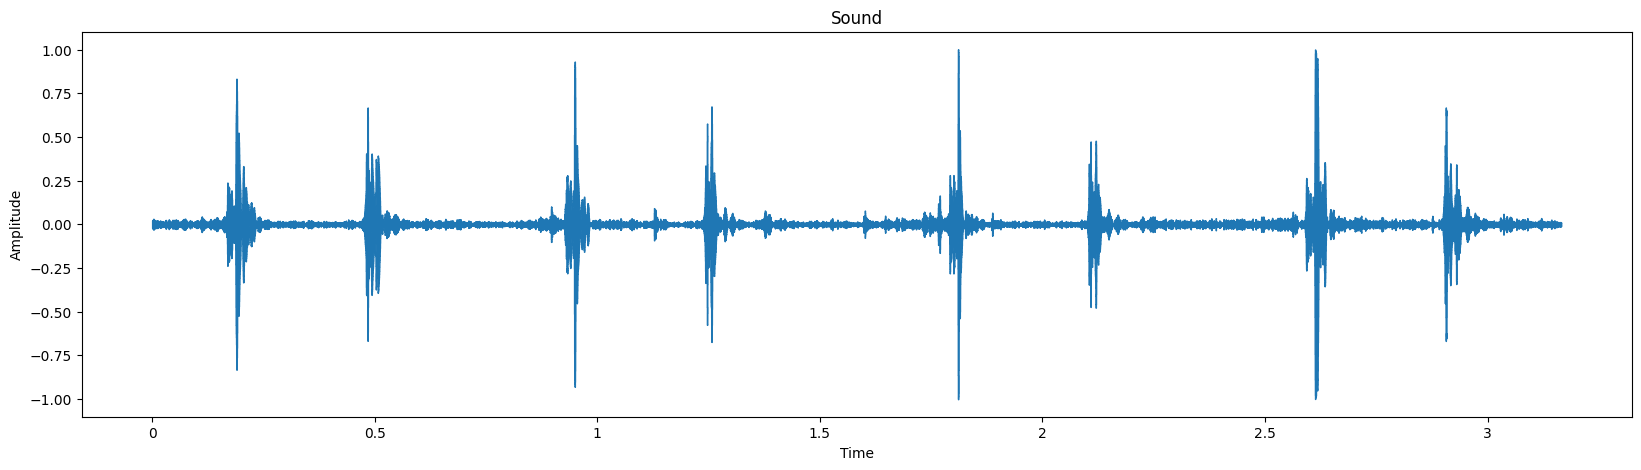

In [18]:
waveform(normal_sample)

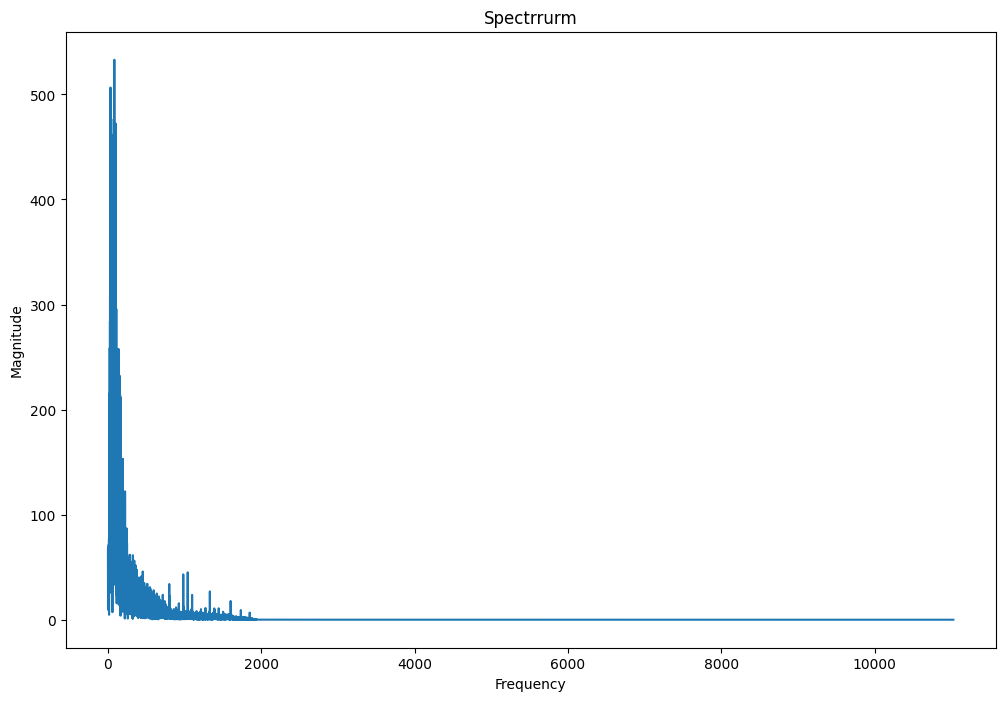

In [19]:
spectrum(normal_sample)

Hop Length Duration (sec): 0.023219954648526078
FFT Window Duration (sec): 0.09287981859410431


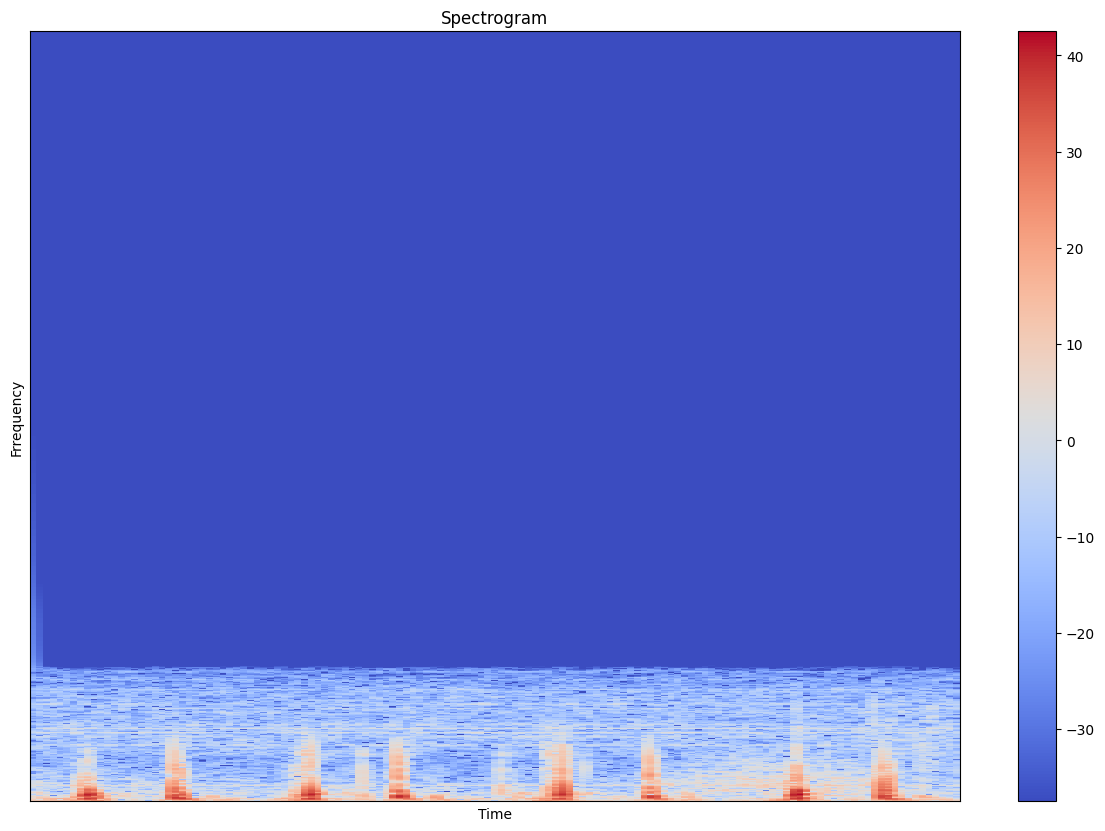

In [20]:
spectrogram(normal_sample)

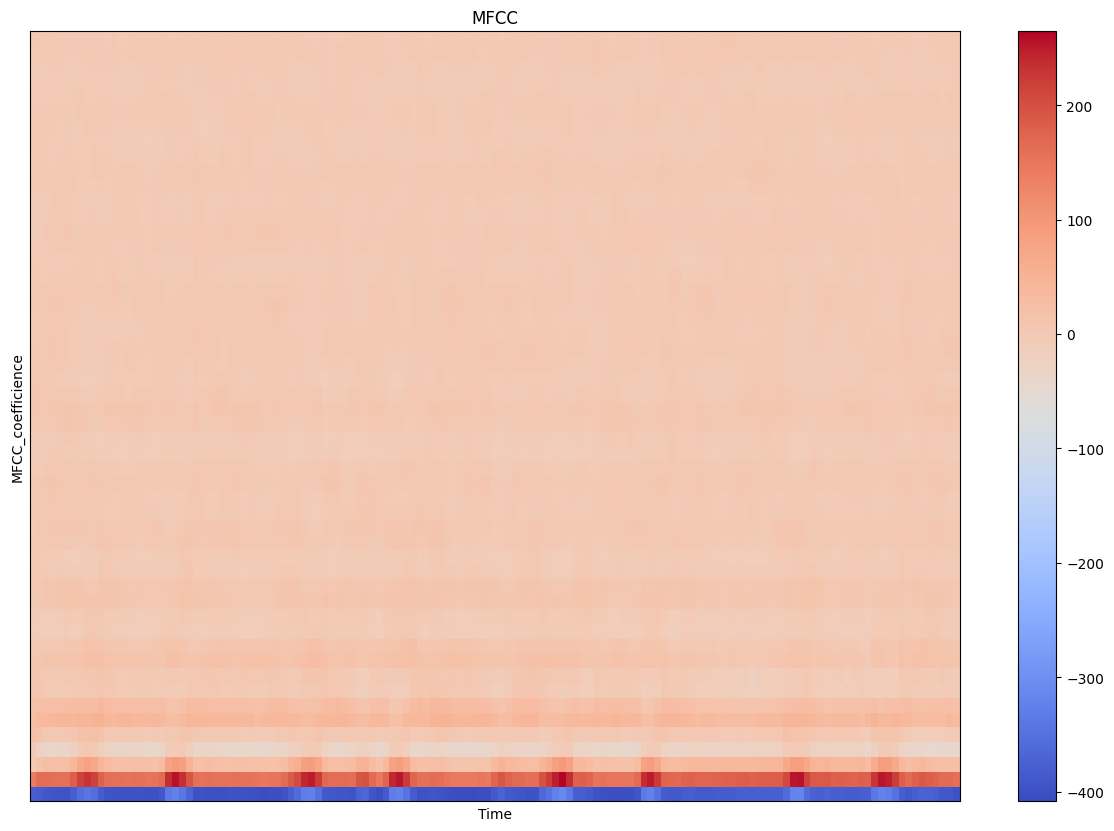

In [21]:
MFCC(normal_sample)

## Feature Engineering

##### ALL Sample rate will have 22050hz freq
##### All Sample max durration of audio to 10
##### Noise Addition, Time stretching, Pitch Shifting.

##### Artifact will be classified as 0 
##### Due to low number of samples, extrahls, extrastole and normal will be classified as 1
##### Murmur will be classified as 2

In [22]:
# function for adding noise
def noise(data, x):
    noise = np.random.randn(len(data))
    data_noise = data + x * noise
    return data_noise

def shift(data, x):
    return np.roll(data, x)

def stretch(data, rate):
    return librosa.effects.time_stretch(y = data, rate = rate)

def pitch(data, rate, sr = 22050):
    return librosa.effects.pitch_shift(y = data, sr = sr, n_steps = rate)

In [23]:
# Map label text to integers (0, 1, 2)

Classes = ["artifact", "murmur", "normal"]
Nb_classes = len(Classes)

# Map int to text labels
label_to_int = {k:v for v, k in enumerate(Classes)}
print(label_to_int)
print("")
int_to_lable = {v:k for k, v in label_to_int.items()}
print(int_to_lable)

{'artifact': 0, 'murmur': 1, 'normal': 2}

{0: 'artifact', 1: 'murmur', 2: 'normal'}


In [24]:
def load_file_data(folder, file_names, duration = 10, sr = 22050):
    input_length = sr * duration
    features = 52
    data = []

    for file_name in file_names:
        try:
            sound_file = folder + file_name
            X, sr = librosa.load(sound_file, sr = sr, duration = duration)
            dur = librosa.get_duration(y = X, sr = sr)

            # pad audio file to same duration
            if round(dur) < duration:
                print("Fixing Audio length",file_name)
                X = librosa.util.fix_length(data = X, size = input_length)

            # Orignal MFCC
            mfccs = np.mean(librosa.feature.mfcc(y = X, sr = sr, n_mfcc = features).T, axis = 0)
            data.append(mfccs.reshape([-1, 1]))

            # stretch 0.8
            stretch_1 = stretch(X, 0.8)
            mfcc_1 = np.mean(librosa.feature.mfcc(y = stretch_1, sr = sr, n_mfcc = features).T, axis = 0)
            data.append(mfcc_1.reshape([-1, 1]))

            # Stretch 1.2
            stretch_2 = stretch(X, 1.2)
            mfcc_2 = np.mean(librosa.feature.mfcc(y = stretch_2, sr = sr, n_mfcc = features).T, axis = 0)
            data.append(mfcc_2.reshape([-1, 1]))

        except Exception as e:
            print("Error in", file_name, "=>", e)

    return data

### Data Standardisation and feature extraction

In [25]:
# 22 KHz
Sample_rate = 22050

# 10 secs
Max_clip_duration = 10

artifact_files = fnmatch.filter(os.listdir(artifact_data), "artifact*.wav")
artifact_sounds = load_file_data(folder = artifact_data, file_names = artifact_files, duration = Max_clip_duration)
artifact_labels = [0 for items in artifact_sounds]

normal_files = fnmatch.filter(os.listdir(normal_data), "normal*.wav")
normal_sounds = load_file_data(folder = normal_data, file_names = normal_files, duration = Max_clip_duration)
normal_labels = [2 for items in normal_sounds]

extrahls_files = fnmatch.filter(os.listdir(extrahls_data), "extrahls*.wav")
extrahls_sounds = load_file_data(folder = extrahls_data, file_names = extrahls_files, duration = Max_clip_duration)
extrahls_labels = [2 for items in extrahls_sounds]

murmur_files = fnmatch.filter(os.listdir(murmur_data), "murmur*.wav")
murmur_sounds = load_file_data(folder = murmur_data, file_names = murmur_files, duration = Max_clip_duration)
murmur_labels = [1 for items in murmur_sounds]

extrastole_files = fnmatch.filter(os.listdir(extrastole_data), "extrastole*.wav")
extrastole_sounds = load_file_data(folder = extrastole_data, file_names = extrastole_files, duration = Max_clip_duration)
extrastole_labels = [2 for items in extrastole_sounds]

print("loeading Done")

Fixing Audio length artifact__201012172012.wav
Fixing Audio length artifact__201105040918.wav
Fixing Audio length artifact__201105041959.wav
Fixing Audio length artifact__201105051017.wav
Fixing Audio length artifact__201105060108.wav
Fixing Audio length artifact__201105061143.wav
Fixing Audio length artifact__201105190800.wav
Fixing Audio length artifact__201105280851.wav
Fixing Audio length artifact__201106010559.wav
Fixing Audio length artifact__201106010602.wav
Fixing Audio length artifact__201106021541.wav
Fixing Audio length artifact__201106030612.wav
Fixing Audio length artifact__201106031558.wav
Fixing Audio length artifact__201106040722.wav
Fixing Audio length artifact__201106040933.wav
Fixing Audio length artifact__201106040947.wav
Fixing Audio length artifact__201106041452.wav
Fixing Audio length artifact__201106050353.wav
Fixing Audio length artifact__201106061233.wav
Fixing Audio length artifact__201106070537.wav
Fixing Audio length artifact__201106070949.wav
Fixing Audio 

In [26]:
print("sample count after loading")
print(f"Artiifact - 0........ {len(artifact_labels)} ")
print(f"murmur - 1....... {len(murmur_labels)}")
print(f"extrahls - 2....... {len(extrahls_labels)}")
print(f"Normal - 2....... {len(normal_labels)}")
print(f"Extrastole - 2....... {len(extrastole_labels)}")

tota_sample = (
    len(artifact_labels) +
    len(murmur_labels) +
    len(extrahls_labels) +
    len(normal_labels) +
    len(extrastole_labels)
)

print(f"total sample is {tota_sample}")

sample count after loading
Artiifact - 0........ 120 
murmur - 1....... 387
extrahls - 2....... 57
Normal - 2....... 1053
Extrastole - 2....... 138
total sample is 1755


In [27]:
# Unlabeled data files
B_Test_files = fnmatch.filter(os.listdir(unlable_data), "Bunlabelledtest*.wav")
B_Test_sounds = load_file_data(folder = unlable_data, file_names = B_Test_files, duration = Max_clip_duration)
B_Test_labels = [-1 for items in B_Test_sounds]

A_Test_files = fnmatch.filter(os.listdir(unlable_data), "Aunlabelledtest*.wav")
A_Test_sounds = load_file_data(folder = unlable_data, file_names = A_Test_files, duration = Max_clip_duration)
A_Test_labels = [-1 for items in A_Test_sounds]

print("Loading of Unlabled data")

Fixing Audio length Bunlabelledtest__101_1305030823364_F.wav
Fixing Audio length Bunlabelledtest__103_1305031931979_A.wav
Fixing Audio length Bunlabelledtest__103_1305031931979_C.wav
Fixing Audio length Bunlabelledtest__106_1306776721273_B.wav
Fixing Audio length Bunlabelledtest__106_1306776721273_D.wav
Fixing Audio length Bunlabelledtest__107_1305654946865_B.wav
Fixing Audio length Bunlabelledtest__109_1305653972028_B.wav
Fixing Audio length Bunlabelledtest__109_1305653972028_D.wav
Fixing Audio length Bunlabelledtest__112_1306243000964_C.wav
Fixing Audio length Bunlabelledtest__113_1306244002866_C.wav
Fixing Audio length Bunlabelledtest__117_1306262456650_B1.wav
Fixing Audio length Bunlabelledtest__118_1306262335509_A.wav
Fixing Audio length Bunlabelledtest__118_1306262335509_A1.wav
Fixing Audio length Bunlabelledtest__118_1306262335509_C2.wav
Fixing Audio length Bunlabelledtest__122_1306325762831_A.wav
Fixing Audio length Bunlabelledtest__122_1306325762831_B.wav
Fixing Audio length B

In [28]:
print("Summary")

print(f"B-unlabeled : {len(B_Test_sounds)}")
print(f"A-unlabeled : {len(A_Test_sounds)}")

print("Lebel check")
print(f"B-labels : {set(B_Test_labels)}")
print(f"A-Labels : {set(A_Test_labels)}")

print("Tots lable")
print(len(B_Test_sounds) + len(A_Test_sounds))

Summary
B-unlabeled : 585
A-unlabeled : 156
Lebel check
B-labels : {-1}
A-Labels : {-1}
Tots lable
741


In [29]:
# Concatinate
# Sounds
x_data = np.concatenate((artifact_sounds, normal_sounds, extrahls_sounds, extrastole_sounds, murmur_sounds))
# Labels
y_data = np.concatenate((artifact_labels, normal_labels, extrahls_labels, extrastole_labels, murmur_labels))

test_x = np.concatenate((A_Test_sounds, B_Test_sounds))
test_y = np.concatenate((A_Test_labels, B_Test_labels))

print("combined data", len(y_data), len(test_y))

combined data 1755 741


In [30]:
# Data Split
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, train_size= 0.8, random_state = 80085)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size= 0.9, random_state = 80085)

# One hot encoding
y_train = np.array(tf.keras.utils.to_categorical(y_train, len(Classes)))
y_test = np.array(tf.keras.utils.to_categorical(y_test, len(Classes)))
y_val = np.array(tf.keras.utils.to_categorical(y_val, len(Classes)))
test_y = np.array(tf.keras.utils.to_categorical(test_y, len(Classes)))

In [31]:
# Corect the Imbalanced data
Trian_img_count = 578
count_0 = 40 # Artifact
count_1 = 129 # murmur
count_2 = 409 # normal
weight_for_0 = Trian_img_count / (3 * count_0)
weight_for_1 = Trian_img_count / (3 * count_1)
weight_for_2 = Trian_img_count / (3 * count_2)
class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2}
class_weight

{0: 4.816666666666666, 1: 1.4935400516795865, 2: 0.4710676446617767}

### LSTM modeling

In [32]:
# Add variables for easy processing
X_train_lstm = X_train
X_val_lstm = X_test
X_test_lstm = X_val

y_train_lstm = y_train
y_val_lstm = y_test
y_test_lstm = y_val

In [33]:
# model
lstm_model = Sequential([
    tf.keras.layers.Input(shape = (52, 1)),

    # CNN Layers
    Conv1D(2048, kernel_size=5, strides=1, padding="same", activation="relu"),
    MaxPooling1D(pool_size=2, strides=2, padding="same"),
    BatchNormalization(),

    Conv1D(1024, kernel_size=5, strides=1, padding="same", activation="relu"),
    MaxPooling1D(pool_size=2, strides=2, padding="same"),
    BatchNormalization(),

    Conv1D(512, kernel_size=5, strides=1, padding="same", activation="relu"),
    MaxPooling1D(pool_size=2, strides=2, padding="same"),
    BatchNormalization(),

    # LSTM layers
    LSTM(256, return_sequences=True),
    LSTM(128),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(32, activation="relu"),
    Dropout(0.5),

    # Final output layer Multiclass
    Dense(3, activation="softmax")
])

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 52, 2048)       │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 26, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 2048)       │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 26, 1024)       │    10,486,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 1024)       │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 13, 512)        │     2,621,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 7, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 7, 256)         │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,130,371 (53.90 MB)

 Trainable params: 14,123,203 (53.88 MB)

 Non-trainable params: 7,168 (28.00 KB)

In [34]:
# Train
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

lstm_model.compile(
    optimizer = optimizer,
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

cb = EarlyStopping(patience = 20, monitor = "val_accuracy", mode = "max", restore_best_weights = True)

history = lstm_model.fit(X_train_lstm, y_train_lstm,
                         validation_data = (X_val_lstm, y_val_lstm),
                         batch_size = 8,
                         epochs = 250,
                         class_weight = class_weight,
                         callbacks = cb)

Epoch 1/250
158/158 ━━━━━━━━━━━━━━━━━━━━ 55s 314ms/step - accuracy: 0.5891 - loss: 0.8690 - val_accuracy: 0.5897 - val_loss: 0.9107
Epoch 2/250
158/158 ━━━━━━━━━━━━━━━━━━━━ 52s 328ms/step - accuracy: 0.5511 - loss: 0.7092 - val_accuracy: 0.2963 - val_loss: 0.8253
Epoch 3/250
158/158 ━━━━━━━━━━━━━━━━━━━━ 50s 314ms/step - accuracy: 0.5416 - loss: 0.6969 - val_accuracy: 0.4558 - val_loss: 0.7896
Epoch 4/250
158/158 ━━━━━━━━━━━━━━━━━━━━ 55s 345ms/step - accuracy: 0.5400 - loss: 0.6255 - val_accuracy: 0.7635 - val_loss: 0.6680
Epoch 5/250
158/158 ━━━━━━━━━━━━━━━━━━━━ 49s 312ms/step - accuracy: 0.5883 - loss: 0.6165 - val_accuracy: 0.2963 - val_loss: 0.8001
Epoch 6/250
158/158 ━━━━━━━━━━━━━━━━━━━━ 50s 315ms/step - accuracy: 0.5693 - loss: 0.5672 - val_accuracy: 0.6325 - val_loss: 0.7162
Epoch 7/250
158/158 ━━━━━━━━━━━━━━━━━━━━ 50s 314ms/step - accuracy: 0.6112 - loss: 0.5458 - val_accuracy: 0.7635 - val_loss: 0.6504
Epoch 8/250
158/158 ━━━━━━━━━━━━━━━━━━━━ 49s 311ms/step - accuracy: 0.6041 -

In [35]:
lstm_model.evaluate(X_val_lstm, y_val_lstm)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 0.9573 - loss: 0.1349


[0.13486362993717194, 0.9572649598121643]

### Loss = 0.1561, Accuracy  =  95%
### MOdel might be overfitted due to class imbalance

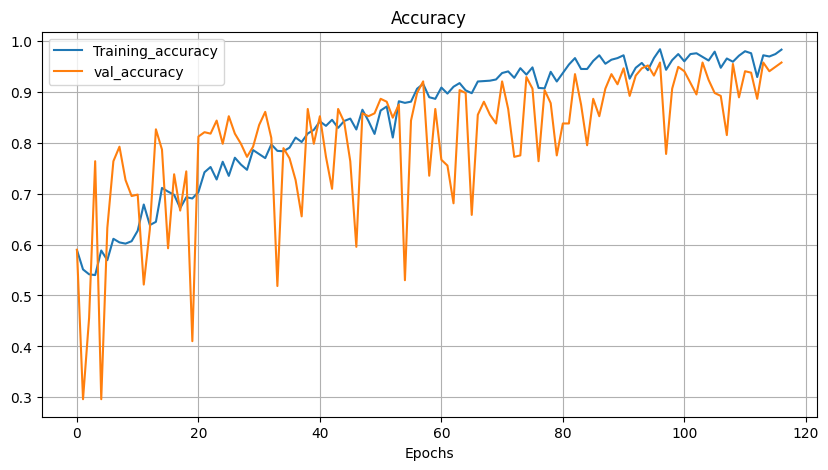

In [36]:
def plot_loss_curves(history):

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    epochs = range(len(history.history["loss"]))

    plt.figure(figsize = (10,5))
    plt.grid()
    plt.plot(epochs, accuracy, label = "Training_accuracy")
    plt.plot(epochs, val_accuracy, label = "val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

plot_loss_curves(history)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step


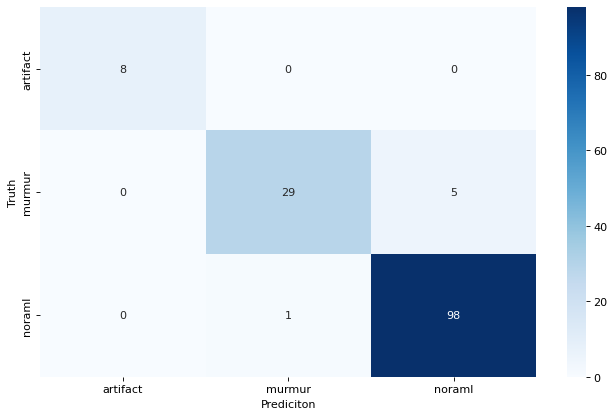

In [37]:
Classes = ["artifact", "murmur", "noraml"]

preds = lstm_model.predict(X_test_lstm)
classpreds = [np.argmax(t) for t in preds]
y_testclass = [np.argmax(t) for t in y_test_lstm]
cm = confusion_matrix(y_testclass, classpreds)

plt.figure(figsize=(10,6), dpi = 80, facecolor = "w", edgecolor="k")
ax = sns.heatmap(cm, cmap = "Blues", annot = True, fmt = "d", xticklabels = Classes, yticklabels = Classes)

plt.title("")
plt.xlabel("Prediciton")
plt.ylabel("Truth")
plt.show(ax)

In [38]:
print(classification_report(y_testclass, classpreds, target_names = Classes))

              precision    recall  f1-score   support

    artifact       1.00      1.00      1.00         8
      murmur       0.97      0.85      0.91        34
      noraml       0.95      0.99      0.97        99

    accuracy                           0.96       141
   macro avg       0.97      0.95      0.96       141
weighted avg       0.96      0.96      0.96       141



## Prediction

In [39]:
def heart_predicition(file_path, duration = 10, sr = 22050):
    classes = ["artifact", "murmur", "normal"]
    input_length = sr * duration

    # Load Audio
    X, sr = librosa.load(file_path, sr = sr, duration = duration)
    dur = librosa.get_duration(y = X, sr = sr)

    # Fix length (new librosa API)
    if round(dur) < duration:
        X = librosa.util.fix_length(data = X, size = input_length)
    
    # Extract MFCC
    mfccs = np.mean(librosa.feature.mfcc(
        y = X,
        sr = sr,
        n_mfcc = 52,
        n_fft = 512,
        hop_length = 2048,
    ).T, axis = 0)

    mfcc_input = mfccs.reshape(1, 52, 1)

    # Predict
    raw_predict = lstm_model.predict(mfcc_input)

    pred_class = classes[np.argmax(raw_predict)]
    confidence = float(np.max(raw_predict))

    return pred_class, confidence

### Test

In [40]:
file_path = r"C:\Users\Sandeep\.cache\kagglehub\datasets\abdallahaboelkhair\heartbeat-sound\versions\1\murmur_2.wav" # change and test with differrent files
pred, conf = heart_predicition(file_path)
print("Prediction", pred)
print("Confidence", conf)

C:\Users\Sandeep\AppData\Local\Temp\ipykernel_45316\1615356350.py:6: UserWarning: PySoundFile failed. Trying audioread instead.
  X, sr = librosa.load(file_path, sr = sr, duration = duration)
c:\Users\Sandeep\anaconda3\envs\new_env\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Sandeep\\.cache\\kagglehub\\datasets\\abdallahaboelkhair\\heartbeat-sound\\versions\\1\\murmur_2.wav'

In [41]:
# Save trained model as HDF5, (.h5) format

lstm_model.save("lstm_model1.keras")

print("model_saved.... as lstm_model.keras")

model_saved.... as lstm_model.keras


### More in code 
### 1) Hyperparameter tuning.
### 2) Code on PEP 8 Style
### 3) Breif description of stecturn, stectogram and MFCC where the code is.